# Analysis: PCA trajectories, dPCA, spatial separation

Load stage-2 checkpoint, collect trials, analyse hidden-state geometry.

In [ ]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src import BioLeakyRNN, CuedTargetWithDistractorsV3
from src.analysis import (
    collect_trials, filter_trials, select_trials,
    fit_pca_on_trials, get_aligned_pca_segments,
    compute_median_and_band, compute_mean_and_sem,
    dpca_marginals, collect_aligned_hidden_by_label, make_condition_mean_tensor,
    plot_spatial_separation_pca, print_centroid_distances, compare_spatial_separation,
)
from src.plotting import (
    plot_pca_trajectories, plot_pca_trajectories_by_outcome,
    plot_pc_timecourses, plot_two_group_pc_timecourses,
    plot_two_group_median_trajectories,
    plot_trialtype_panel, plot_dpca_components, plot_dpca_plane,
)

device = 'cpu'
print('device:', device)

## Load model

In [2]:
def make_model():
    return BioLeakyRNN(
        input_size=7, hidden_size=128, output_size=2,
        dt=20.0, tau=100.0, activation='softplus', sigma_rec=0.05,
        use_ei=True, exc_ratio=0.7, use_dale=True, mask_seed=42,
    )

def make_env_stage2():
    return CuedTargetWithDistractorsV3(dt=20, cue_strength=1.0,
                                       p_distractor_trial=0.6, distractor_strength=1.0)

model = make_model().to(device)
model.load_state_dict(torch.load('../checkpoints/stage2.pt', weights_only=True)['state_dict'])
model.eval()
print('Loaded stage2 checkpoint.')

Loaded stage2 checkpoint.


## Collect trials

In [3]:
trials = collect_trials(model, make_env_stage2, n_trials=5000, device=device)
print(f'Collected {len(trials)} trials')
print(Counter(tr['train_outcome'] for tr in trials))

Collected 5000 trials
Counter({'correct': 4615, 'false_alarm': 364, 'abort': 13, 'miss': 8})


## PCA on hidden states

In [4]:
pca, trial_proj, explained = fit_pca_on_trials(trials, n_components=3)
print('Explained variance:', explained)

Explained variance: [0.48902945 0.22452416 0.11446651]


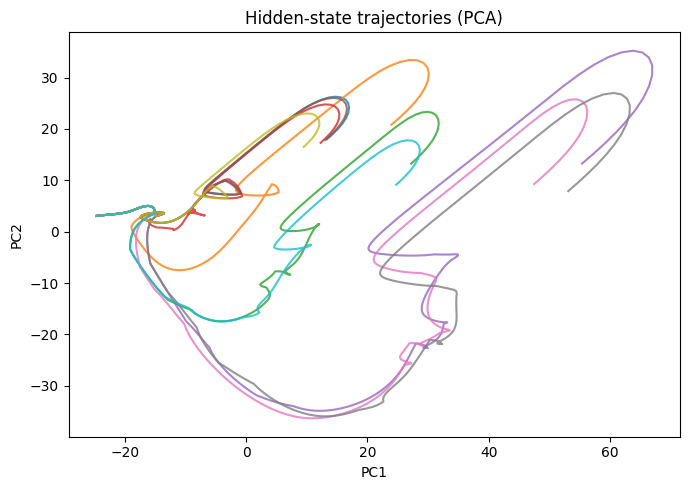

In [5]:
plot_pca_trajectories(trials, trial_proj, max_trials=10)

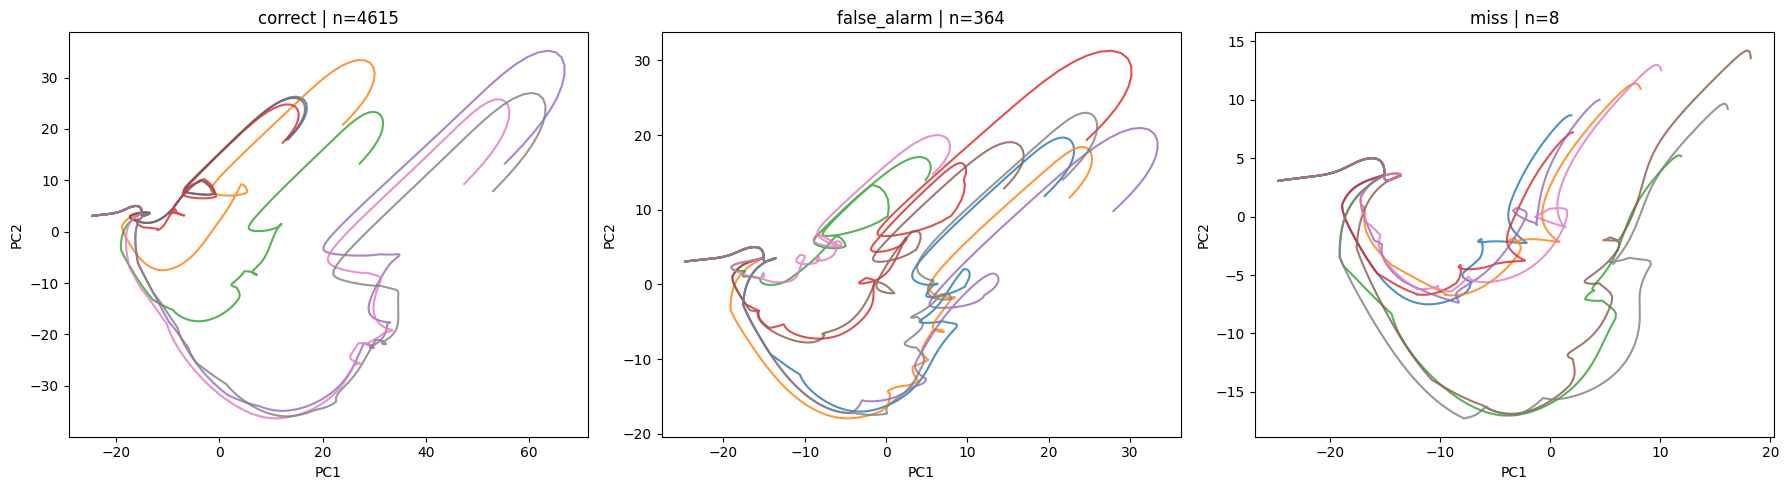

In [6]:
plot_pca_trajectories_by_outcome(trials, trial_proj,
                                  outcomes=("correct", "false_alarm", "miss"),
                                  max_per_group=8)

## Event-aligned time courses

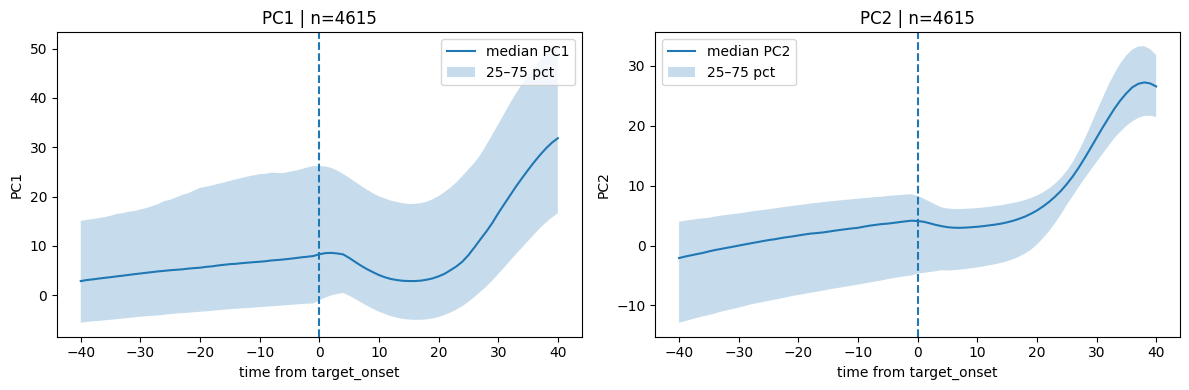

In [7]:
plot_pc_timecourses(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    stat_mode='median', q_low=25, q_high=75,
    train_outcome='correct',
)

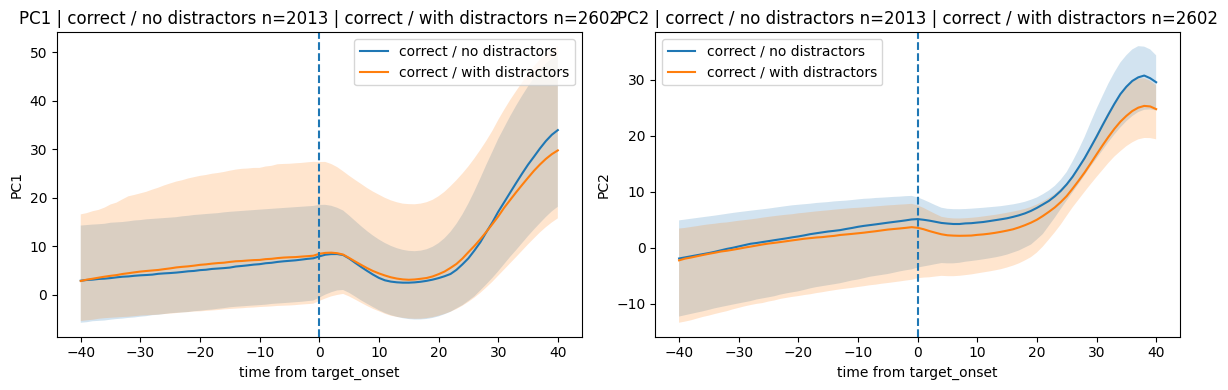

In [8]:
plot_two_group_pc_timecourses(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    group1_kwargs={'train_outcome': 'correct', 'has_distractors': False},
    group2_kwargs={'train_outcome': 'correct', 'has_distractors': True},
    group1_label='correct / no distractors',
    group2_label='correct / with distractors',
    stat_mode='median', q_low=25, q_high=75,
)

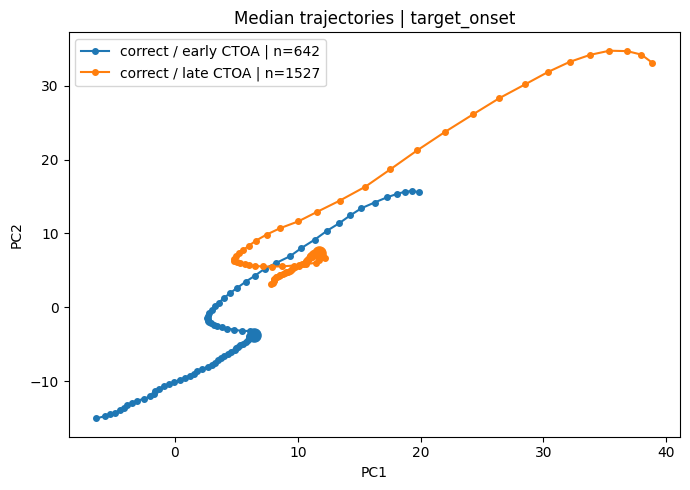

In [10]:
plot_two_group_median_trajectories(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    group1_kwargs={'train_outcome': 'correct', 'ctoa_bin_max': 2},
    group2_kwargs={'train_outcome': 'correct', 'ctoa_bin_min': 7},
    group1_label='correct / early CTOA',
    group2_label='correct / late CTOA',
)

## Panel: outcomes × CTOA × spatial location

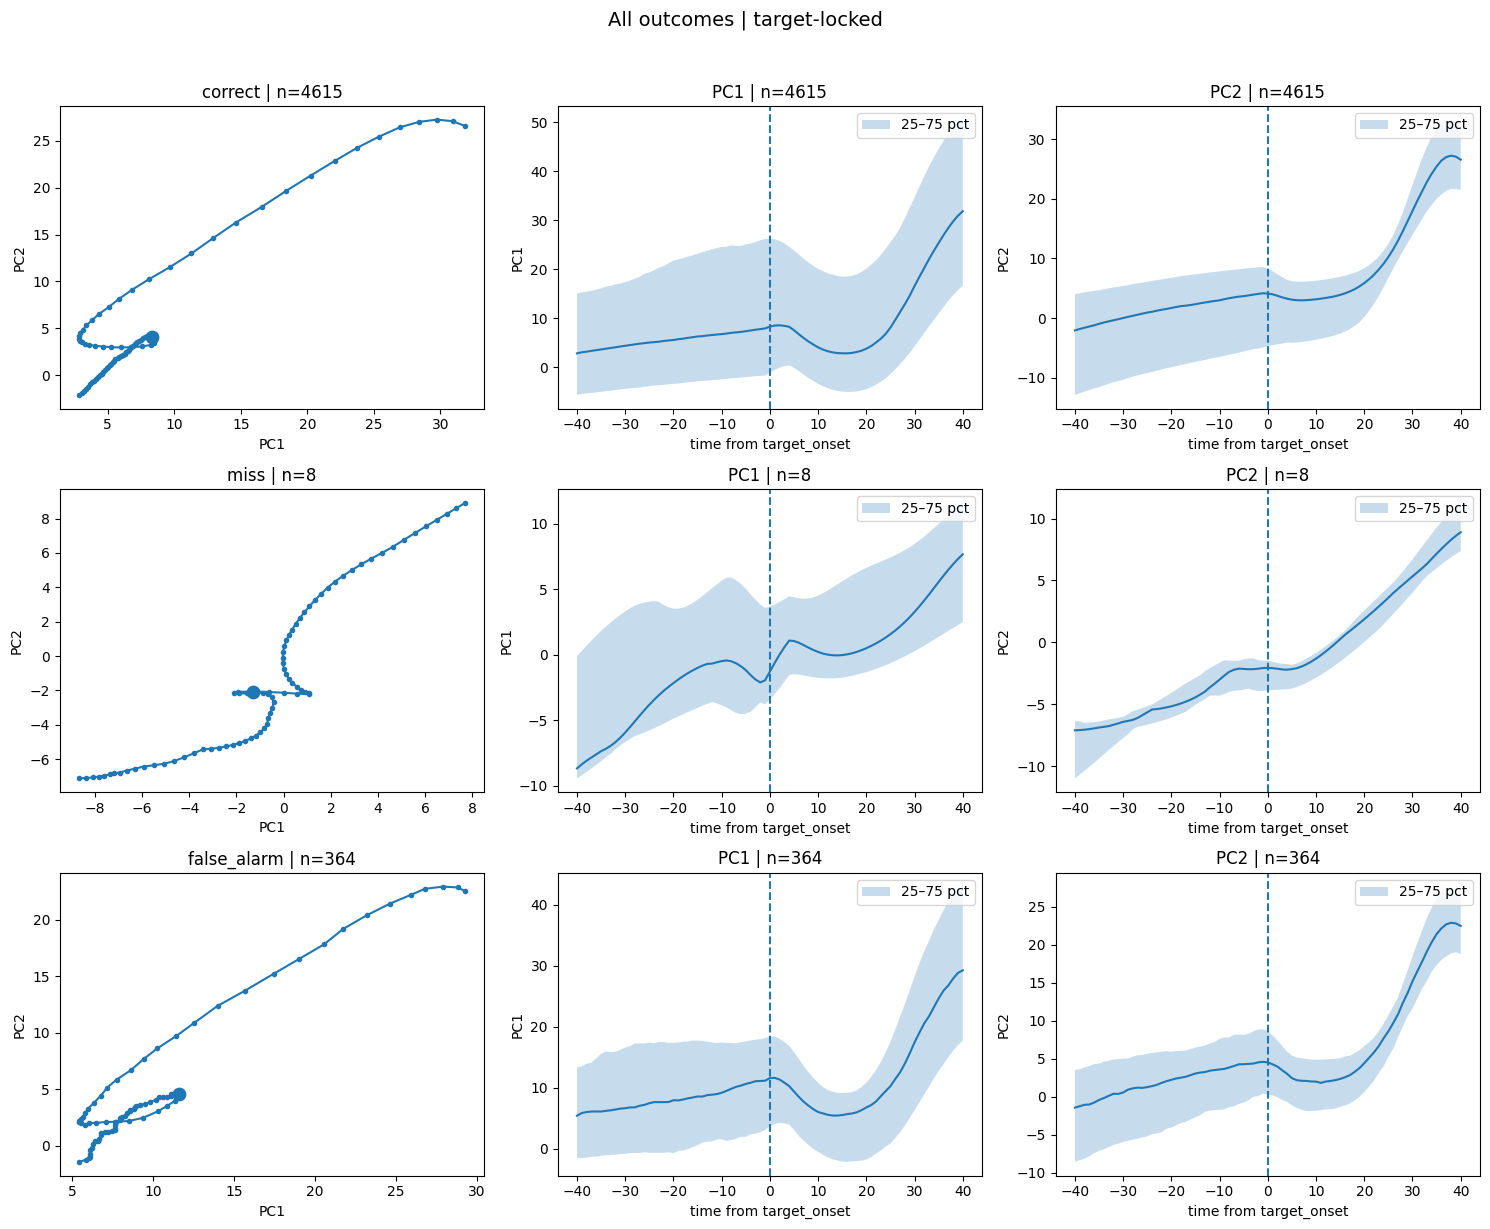

In [12]:
plot_trialtype_panel(
    trials, trial_proj,
    group_specs=[
        {'label': 'correct',     'train_outcome': 'correct'},
        {'label': 'miss',        'train_outcome': 'miss'},
        {'label': 'false_alarm', 'train_outcome': 'false_alarm'},
    ],
    align_key='target_onset', window_before=40, window_after=40,
    stat_mode='median', q_low=25, q_high=75,
    suptitle='All outcomes | target-locked',
)

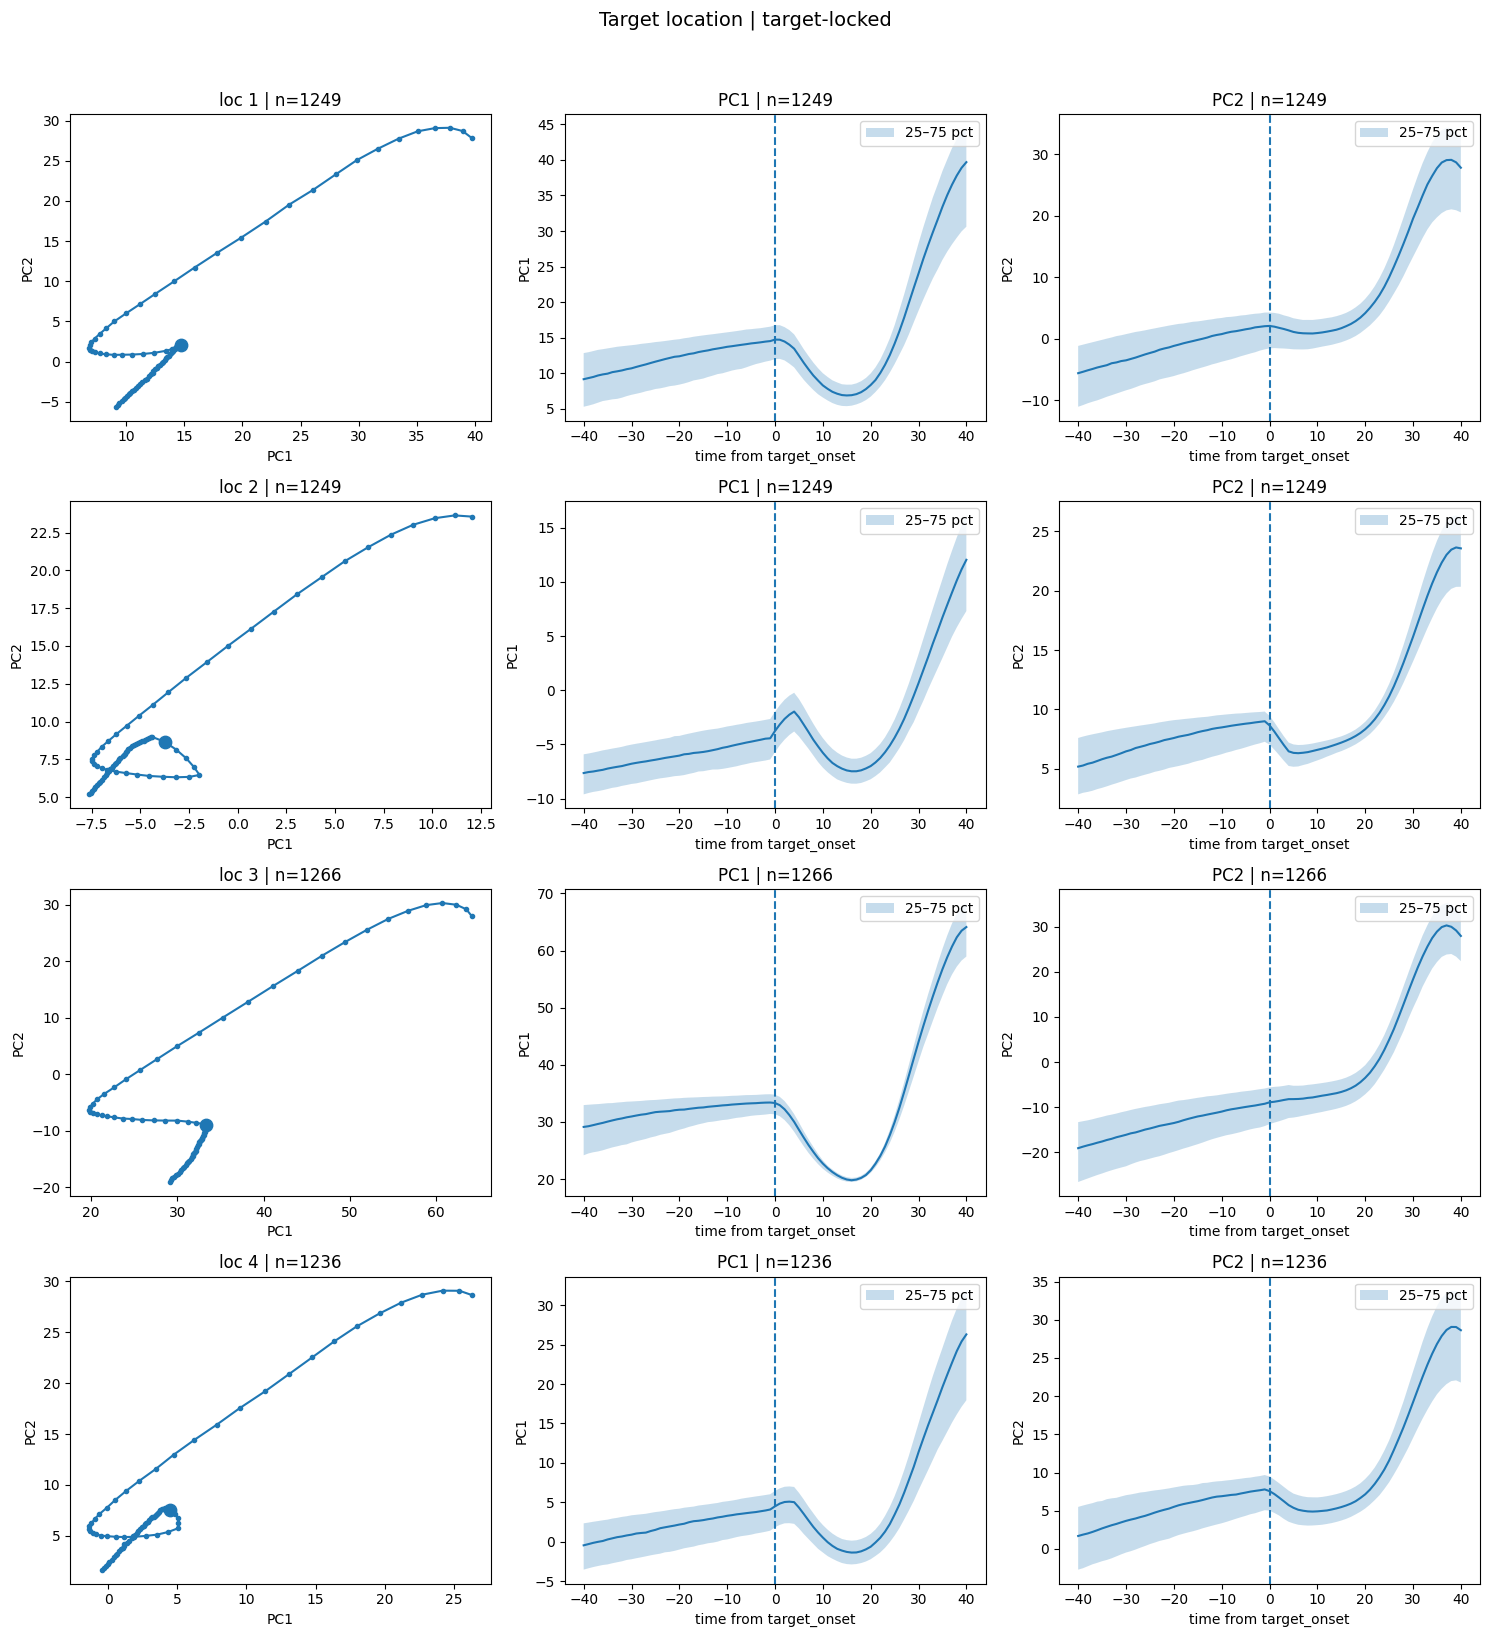

In [13]:
plot_trialtype_panel(
    trials, trial_proj,
    group_specs=[{'label': f'loc {i}', 'target_loc': i} for i in range(1, 5)],
    align_key='target_onset', window_before=40, window_after=40,
    stat_mode='median', q_low=25, q_high=75,
    suptitle='Target location | target-locked',
)

## False alarms vs aborts

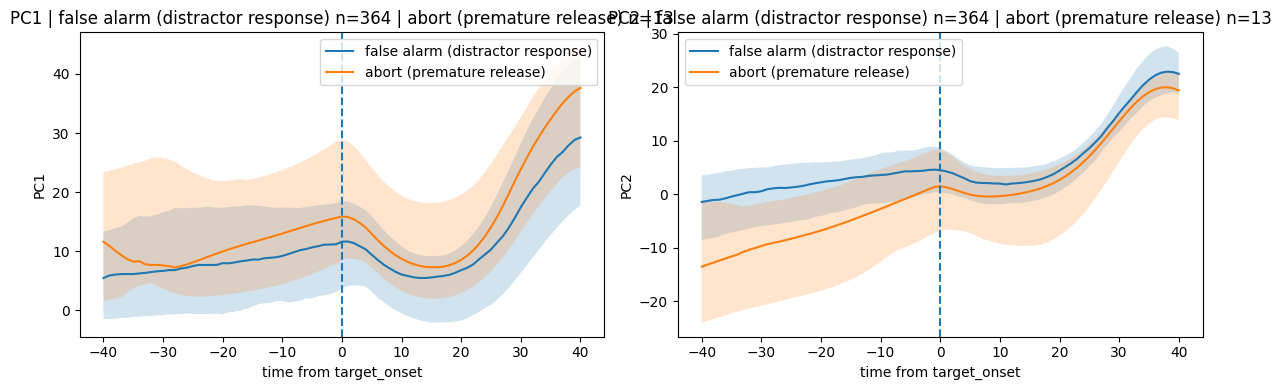

In [14]:
plot_two_group_pc_timecourses(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    group1_kwargs={'train_outcome': 'false_alarm'},
    group2_kwargs={'train_outcome': 'abort'},
    group1_label='false alarm (distractor response)',
    group2_label='abort (premature release)',
    stat_mode='median', q_low=25, q_high=75,
)

## dPCA: CTOA condition

In [15]:
by_ctoa, rel_time = collect_aligned_hidden_by_label(
    trials,
    label_fn=lambda tr: tr.get('ctoa_bin'),
    align_key='target_onset', window_before=40, window_after=40,
)
X_ctoa, ctoa_labels, ctoa_counts = make_condition_mean_tensor(by_ctoa, min_trials=5)
print('CTOA bins:', ctoa_labels, '  counts:', ctoa_counts)

res_ctoa = dpca_marginals(X_ctoa, n_components=3)
res_ctoa['rel_time'] = rel_time
res_ctoa['labels']   = ctoa_labels

CTOA bins: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]   counts: [66, 220, 369, 480, 662, 712, 785, 726, 602, 378]


In [ ]:
plot_dpca_components(res_ctoa, component_key='Z_time', explained_key='explained_time',
                     title_prefix='time', n_plot=3)
plot_dpca_components(res_ctoa, component_key='Z_cond', explained_key='explained_cond',
                     title_prefix='CTOA', n_plot=3)
plot_dpca_plane(res_ctoa, xlabel='CTOA-dPC1', ylabel='CTOA-dPC2',
                title='CTOA-demixed trajectories')

## Median trajectories: correct with vs without distractors

In [ ]:
plot_two_group_median_trajectories(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    group1_kwargs={'train_outcome': 'correct', 'has_distractors': False},
    group2_kwargs={'train_outcome': 'correct', 'has_distractors': True},
    group1_label='correct / no distractors',
    group2_label='correct / with distractors',
)

## CTOA x target position

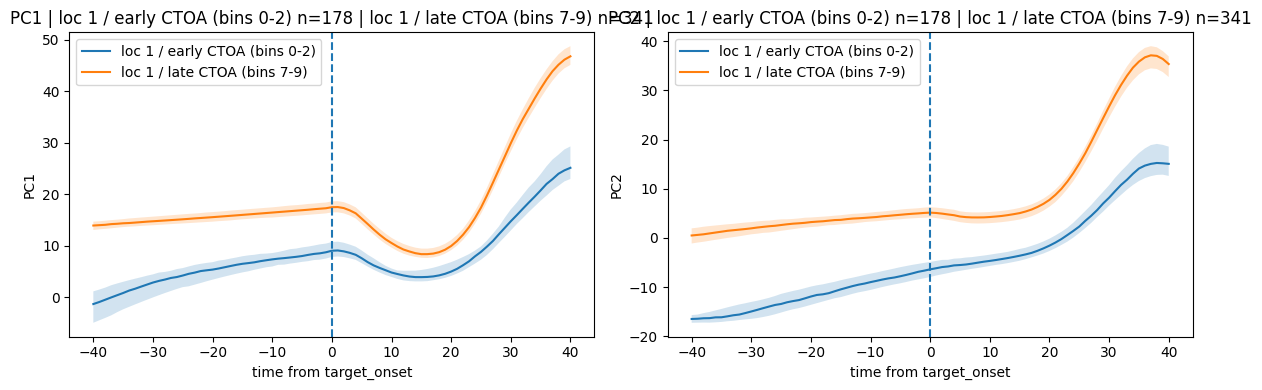

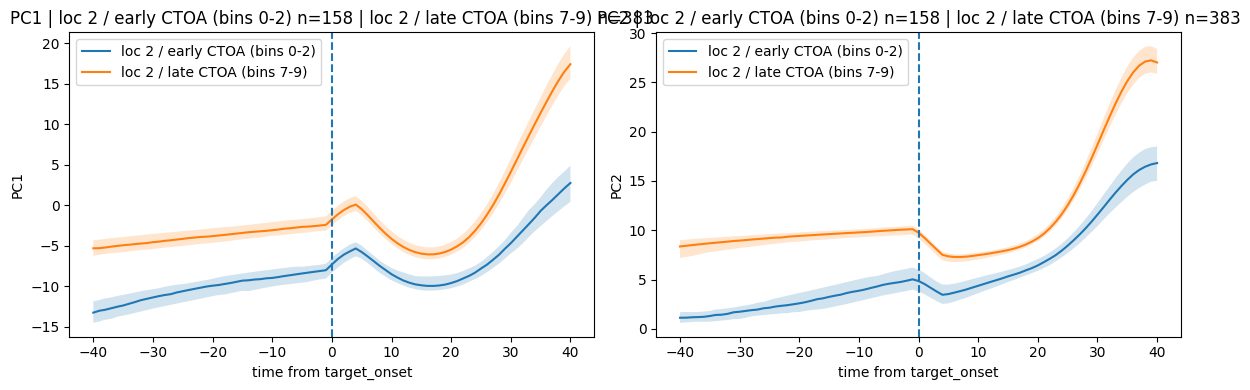

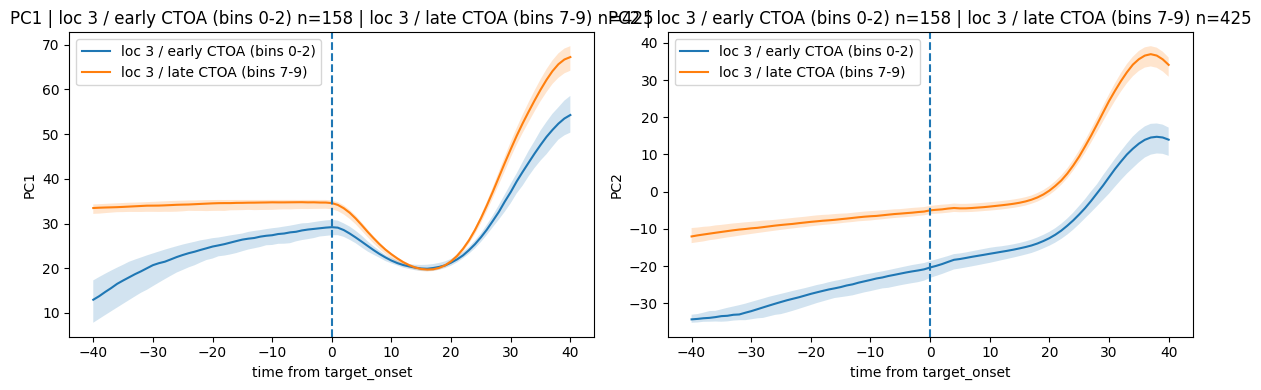

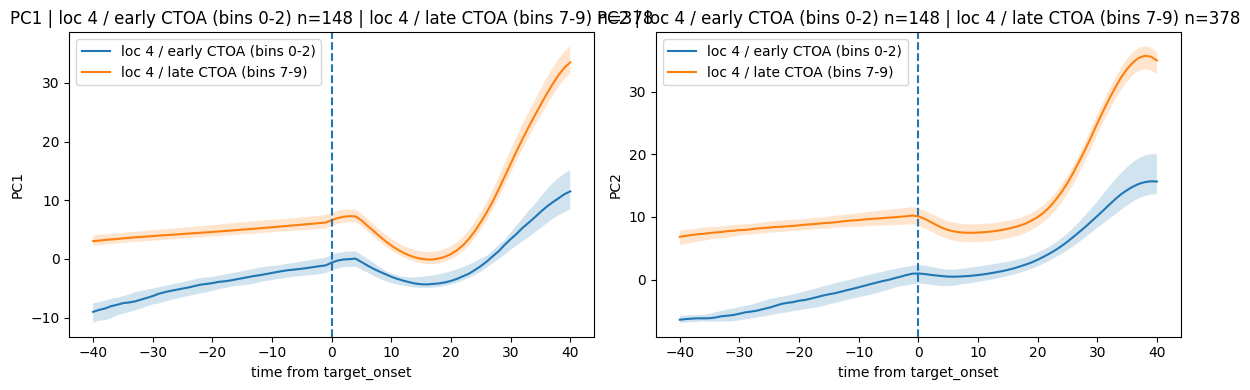

In [17]:
for loc in range(1, 5):
    plot_two_group_pc_timecourses(
        trials, trial_proj,
        align_key='target_onset', window_before=40, window_after=40,
        group1_kwargs={'train_outcome': 'correct', 'target_loc': loc, 'ctoa_bin_max': 2},
        group2_kwargs={'train_outcome': 'correct', 'target_loc': loc, 'ctoa_bin_min': 7},
        group1_label=f'loc {loc} / early CTOA (bins 0-2)',
        group2_label=f'loc {loc} / late CTOA (bins 7-9)',
        stat_mode='median', q_low=25, q_high=75,
    )

## CTOA x distractor presence

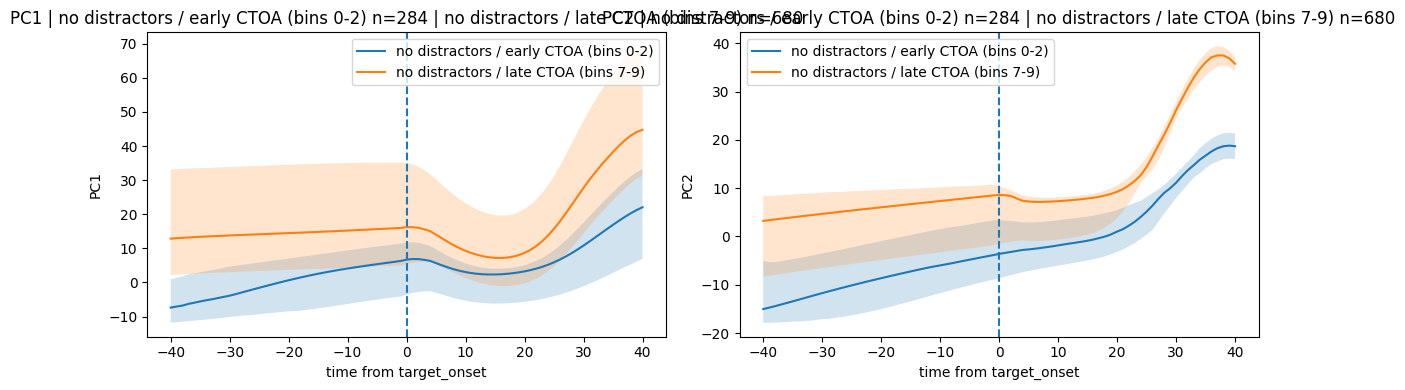

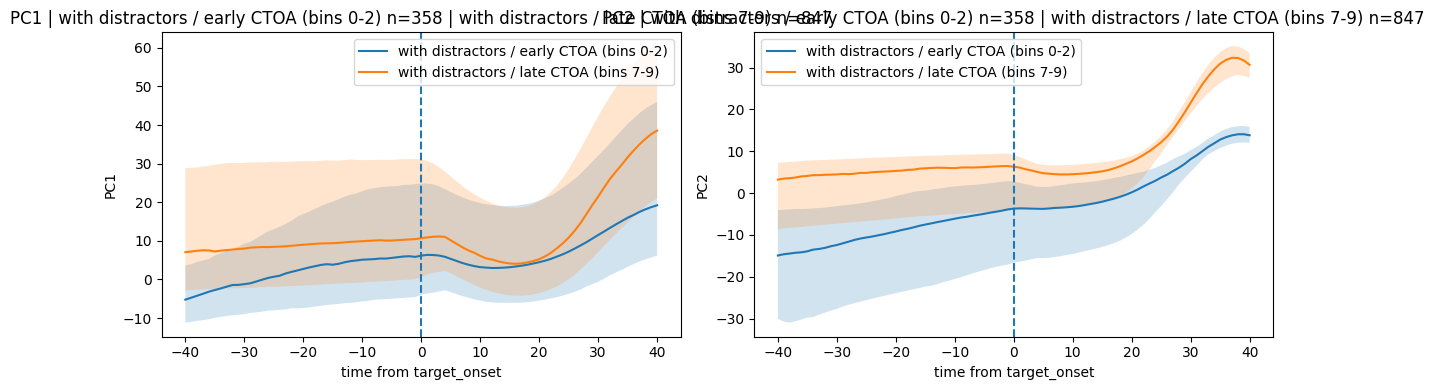

In [18]:
for has_d, label in [(False, 'no distractors'), (True, 'with distractors')]:
    plot_two_group_pc_timecourses(
        trials, trial_proj,
        align_key='target_onset', window_before=40, window_after=40,
        group1_kwargs={'train_outcome': 'correct', 'has_distractors': has_d, 'ctoa_bin_max': 2},
        group2_kwargs={'train_outcome': 'correct', 'has_distractors': has_d, 'ctoa_bin_min': 7},
        group1_label=f'{label} / early CTOA (bins 0-2)',
        group2_label=f'{label} / late CTOA (bins 7-9)',
        stat_mode='median', q_low=25, q_high=75,
    )

## Spatial separation analysis

Does the network represent target location in its hidden state?

In [19]:
# Collect more trials for spatial analysis (need enough per location)
trials_spatial = collect_trials(model, make_env_stage2, n_trials=2000, device=device)
print(Counter(tr['train_outcome'] for tr in trials_spatial))

Counter({'correct': 1829, 'false_alarm': 159, 'abort': 6, 'miss': 6})


correct: 1829


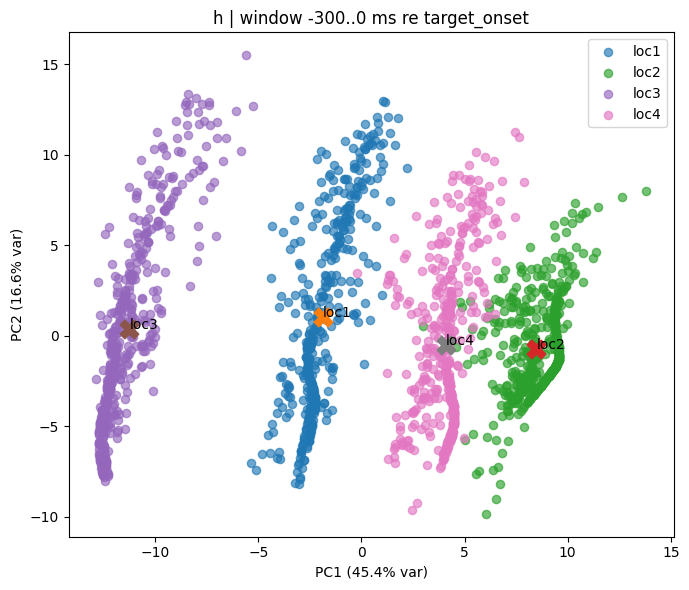

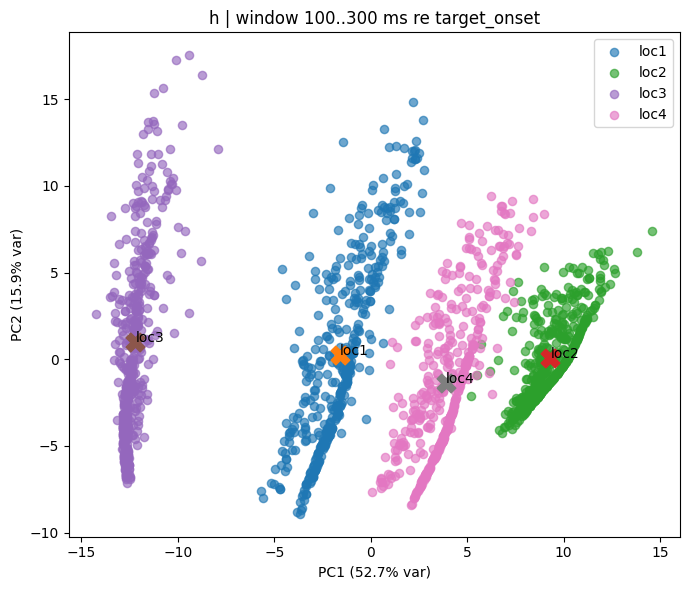

Pre-target
[[ 0.    10.504  9.403  6.174]
 [10.504  0.    19.757  4.386]
 [ 9.403 19.757  0.    15.371]
 [ 6.174  4.386 15.371  0.   ]]
Post-target
[[ 0.    10.928 10.621  5.748]
 [10.928  0.    21.539  5.595]
 [10.621 21.539  0.    16.287]
 [ 5.748  5.595 16.287  0.   ]]


array([[ 0.        , 10.92753887, 10.62081242,  5.74775791],
       [10.92753887,  0.        , 21.53905106,  5.59532261],
       [10.62081242, 21.53905106,  0.        , 16.28718758],
       [ 5.74775791,  5.59532261, 16.28718758,  0.        ]])

In [20]:
# All correct trials: pre- vs post-target
trials_correct = filter_trials(trials_spatial, outcome='correct')
print('correct:', len(trials_correct))

res_pre  = plot_spatial_separation_pca(trials_correct, align_key='target_onset', window_ms=(-300, 0))
res_post = plot_spatial_separation_pca(trials_correct, align_key='target_onset', window_ms=(100, 300))

print_centroid_distances(res_pre,  name='Pre-target')
print_centroid_distances(res_post, name='Post-target')

hit (distractor): 1020,  FA (distractor): 159
hit: n=1020,  false_alarm: n=159

--- hit pre-target ---


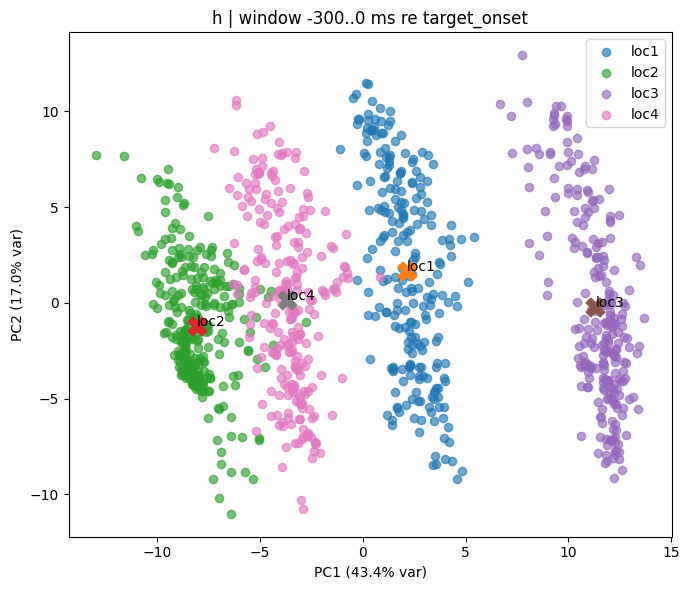

hit pre
[[ 0.    10.626  9.374  6.029]
 [10.626  0.    19.441  4.599]
 [ 9.374 19.441  0.    15.025]
 [ 6.029  4.599 15.025  0.   ]]

--- hit post-target ---


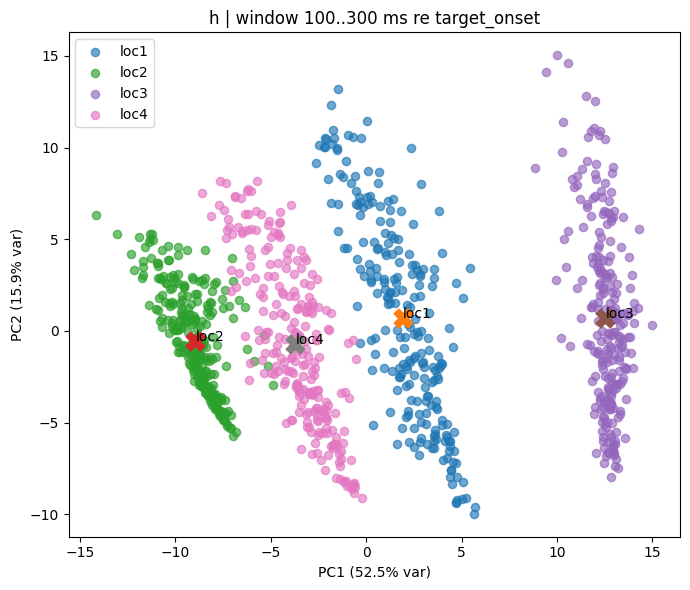

hit post
[[ 0.    10.928 10.625  5.791]
 [10.928  0.    21.518  5.24 ]
 [10.625 21.518  0.    16.305]
 [ 5.791  5.24  16.305  0.   ]]

--- false_alarm pre-target ---


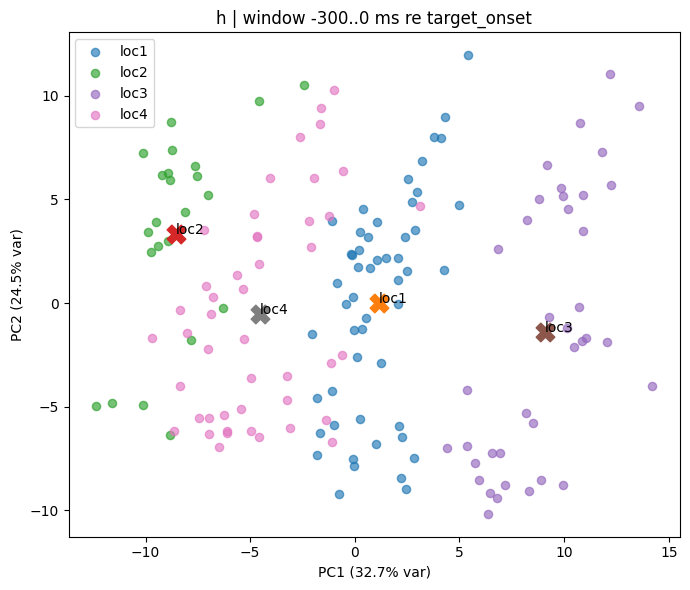

false_alarm pre
[[ 0.    10.263  8.041  5.727]
 [10.263  0.    18.248  5.559]
 [ 8.041 18.248  0.    13.65 ]
 [ 5.727  5.559 13.65   0.   ]]

--- false_alarm post-target ---


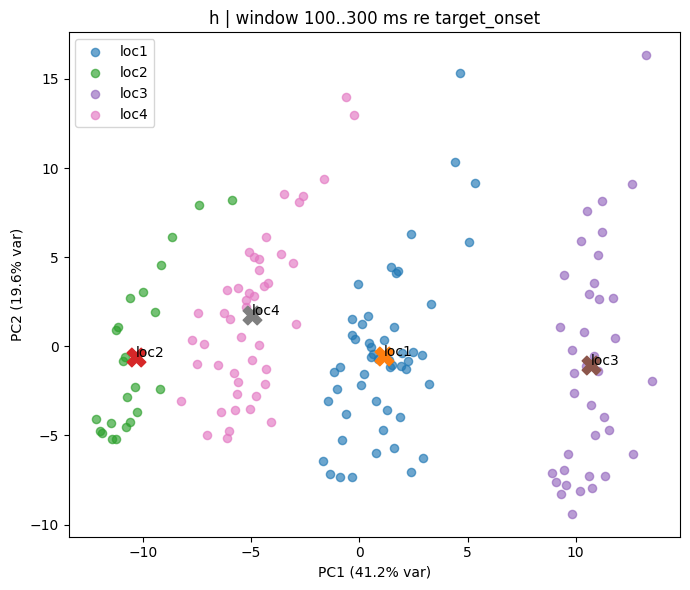

false_alarm post
[[ 0.    11.476  9.571  6.525]
 [11.476  0.    21.039  5.848]
 [ 9.571 21.039  0.    15.913]
 [ 6.525  5.848 15.913  0.   ]]


{'A': {'pre': {'X': array([[ 0.5237    ,  2.081702  ,  4.076482  , ...,  0.3366807 ,
            0.39307854,  5.8978095 ],
          [ 0.02644894,  3.9168334 ,  8.737863  , ...,  0.39129066,
            0.59928894, 10.639935  ],
          [ 0.24065118,  2.7145238 ,  2.1725137 , ...,  0.6977759 ,
            0.84982973,  4.630837  ],
          ...,
          [ 1.1075453 ,  2.7565057 ,  3.1579566 , ...,  0.1442319 ,
            0.11017572,  8.766815  ],
          [ 0.15340675,  1.881906  ,  0.37026688, ...,  0.3906226 ,
            0.2863803 ,  5.868975  ],
          [ 0.19730236,  1.3933349 ,  0.48543712, ...,  0.59138066,
            0.541941  ,  4.2842703 ]], dtype=float32),
   'X_plot': array([[ 2.2410157 , -0.19759975,  0.29086798, ..., -1.2306054 ,
           -0.9167229 , -0.282948  ],
          [-0.80364555,  1.4501579 ,  2.3801548 , ..., -0.9184105 ,
           -0.3342691 ,  2.0106688 ],
          [ 0.5079118 ,  0.37060857, -0.5625134 , ...,  0.8337082 ,
            0.37339854, -

In [21]:
# Correct+distractor vs false-alarm: does pre-target geometry predict outcome?
trials_hit = filter_trials(trials_spatial, outcome='correct',     require_distractors=True)
trials_fa  = filter_trials(trials_spatial, outcome='false_alarm', require_distractors=True)
print(f'hit (distractor): {len(trials_hit)},  FA (distractor): {len(trials_fa)}')

compare_spatial_separation(trials_hit, trials_fa, label_A='hit', label_B='false_alarm')

miss: 6


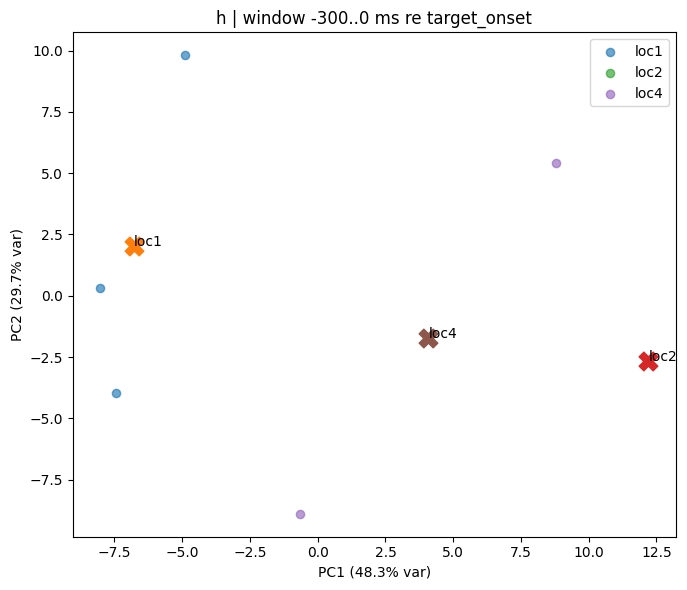

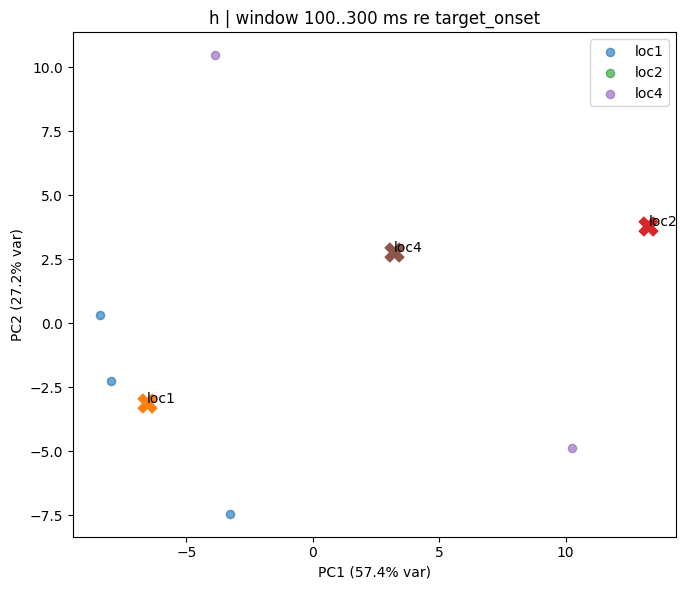

Miss pre-target
[[ 0.    19.572    nan 11.508]
 [19.572  0.       nan  8.179]
 [   nan    nan    nan    nan]
 [11.508  8.179    nan  0.   ]]
Miss post-target
[[ 0.    21.012    nan 11.409]
 [21.012  0.       nan 10.133]
 [   nan    nan    nan    nan]
 [11.409 10.133    nan  0.   ]]


In [22]:
trials_miss = filter_trials(trials_spatial, outcome='miss')
print('miss:', len(trials_miss))

if len(trials_miss) > 0:
    res_miss_pre  = plot_spatial_separation_pca(trials_miss, align_key='target_onset', window_ms=(-300, 0))
    res_miss_post = plot_spatial_separation_pca(trials_miss, align_key='target_onset', window_ms=(100, 300))
    print_centroid_distances(res_miss_pre,  name='Miss pre-target')
    print_centroid_distances(res_miss_post, name='Miss post-target')
else:
    print('Not enough miss trials to plot spatial separation.')